In [1]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/checkpoint-5-bogdan-egor/bogdan/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
likes = load_from_disk('dataset-parts/yambda_likes')
dislikes = load_from_disk('dataset-parts/yambda_dislikes')
listens = load_from_disk('dataset-parts/yambda_listens')

likes_table = likes.data.table
dislikes_table = dislikes.data.table
listens_table = listens.data.table


likes_df: pd.DataFrame = pd.DataFrame.from_arrow(likes_table)
dislikes_df: pd.DataFrame = pd.DataFrame.from_arrow(dislikes_table)
listens_df: pd.DataFrame = pd.DataFrame.from_arrow(listens_table)

likes_df['event_type'] = 'like'
dislikes_df['event_type'] = 'dislike'
listens_df['event_type'] = 'listen'

# yambda_df = pd.concat([likes_df, dislikes_df, listens_df], ignore_index=True)
yambda_df = pd.concat([likes_df, dislikes_df], ignore_index=True)

yambda_df = yambda_df.sort_values('timestamp')

yambda_df

,uid,timestamp,item_id,is_organic,event_type
968657,794500,75,5559703,1,dislike
968664,794500,75,2224183,1,dislike
968663,794500,75,1861694,1,dislike
968662,794500,75,2605934,1,dislike
968661,794500,75,1113563,1,dislike
...,...,...,...,...,...
713215,809400,25999905,1264650,1,like
146824,168100,25999910,83561,1,like
360130,411500,25999945,1342000,1,like
933449,411500,25999945,6603749,1,dislike


In [3]:
yambda_df_organic = yambda_df[yambda_df['is_organic'] == 1].drop(['is_organic'], axis=1)

yambda_df_organic

,uid,timestamp,item_id,event_type
968657,794500,75,5559703,dislike
968664,794500,75,2224183,dislike
968663,794500,75,1861694,dislike
968662,794500,75,2605934,dislike
968661,794500,75,1113563,dislike
...,...,...,...,...
146823,168100,25999890,4626898,like
713215,809400,25999905,1264650,like
146824,168100,25999910,83561,like
360130,411500,25999945,1342000,like


In [4]:
weak_ticks = (7 * 24 * 3600) // 5
year_ticks = (365 * 24 * 3600) // 5

weak_ticks, year_ticks

(120960, 6307200)

In [5]:
max_time = yambda_df_organic['timestamp'].max()

test_start = max_time - weak_ticks
train_start = test_start - year_ticks

In [6]:
train_df = yambda_df_organic[
    (yambda_df_organic['timestamp'] >= train_start) &
    (yambda_df_organic['timestamp'] < test_start)
]

test_df = yambda_df_organic[yambda_df_organic['timestamp'] >= test_start]

Количество уникальных айтемов и пользователей

In [7]:
train_df['item_id'].nunique(), train_df['uid'].nunique()

(73212, 7149)

In [8]:
users_activity = train_df['uid'].value_counts()

In [9]:
users_activity.describe()

count    7149.000000
mean       26.318506
std       109.050893
min         1.000000
25%         3.000000
50%        10.000000
75%        25.000000
max      7184.000000
Name: count, dtype: float64

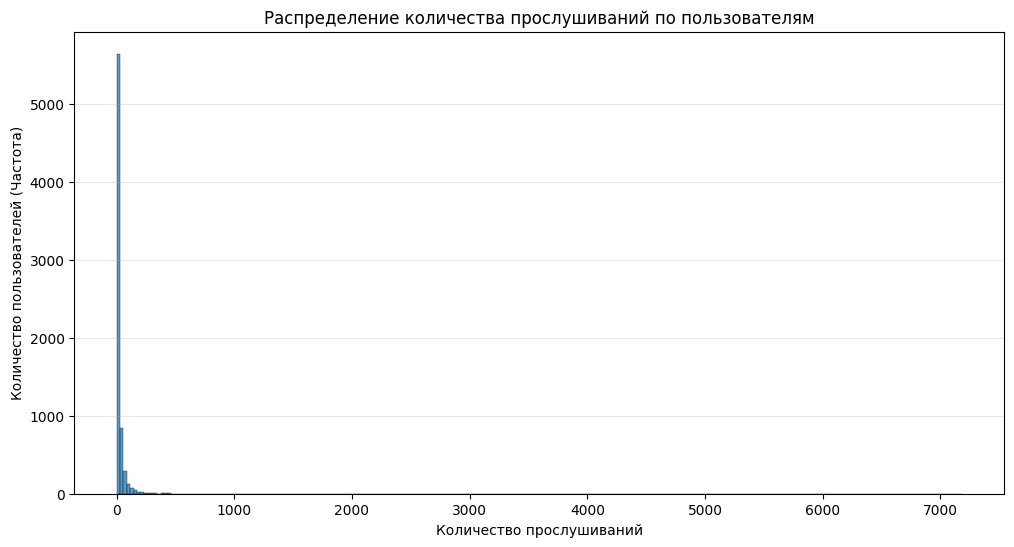

In [10]:
plt.figure(figsize=(12, 6))

sns.histplot(users_activity, bins=250)

plt.title('Распределение количества прослушиваний по пользователям')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (Частота)')
plt.grid(axis='y', alpha=0.3)
plt.show()

<Axes: xlabel='count'>

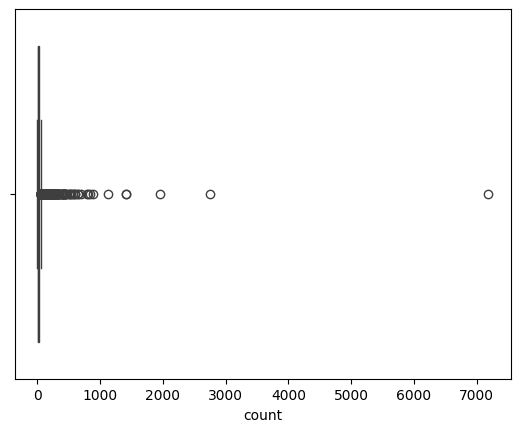

In [11]:
sns.boxplot(x=users_activity)

In [12]:
quantiles = [0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99, 0.999]

for quantile in quantiles:
    print(f'Listens quntile {quantile * 100}%: {users_activity.quantile(quantile)}')

Listens quntile 25.0%: 3.0
Listens quntile 50.0%: 10.0
Listens quntile 75.0%: 25.0
Listens quntile 80.0%: 31.0
Listens quntile 90.0%: 56.0
Listens quntile 95.0%: 90.0
Listens quntile 99.0%: 231.0799999999981
Listens quntile 99.9%: 838.4119999999957


In [13]:

groups = pd.qcut(users_activity, q=[0, 0.3, 0.6, 0.9, 0.95, 1.0], duplicates='drop')

counts = groups.value_counts().sort_index()

print('Users activity distribution')
print(counts)

Users activity distribution
count
(0.999, 4.0]      2258
(4.0, 14.0]       2075
(14.0, 56.0]      2116
(56.0, 90.0]       346
(90.0, 7184.0]     354
Name: count, dtype: int64


Можно увидеть, что активные/"нормальные" пользователи сидят между 60-ым 95-ым перцентилями, я бы даже поднял нижнюю границу до 70

In [14]:
low_threshold = users_activity.quantile(0.7)
high_threshold = users_activity.quantile(0.95)

active_user_ids = users_activity[
    (users_activity >= low_threshold) & 
    (users_activity <= high_threshold)
].index

df_train_active = train_df[train_df['uid'].isin(active_user_ids)].reset_index(drop=True)

In [15]:
df_train_active['uid'].value_counts().describe()

count    1809.000000
mean       40.697070
std        17.799771
min        21.000000
25%        26.000000
50%        35.000000
75%        51.000000
max        90.000000
Name: count, dtype: float64

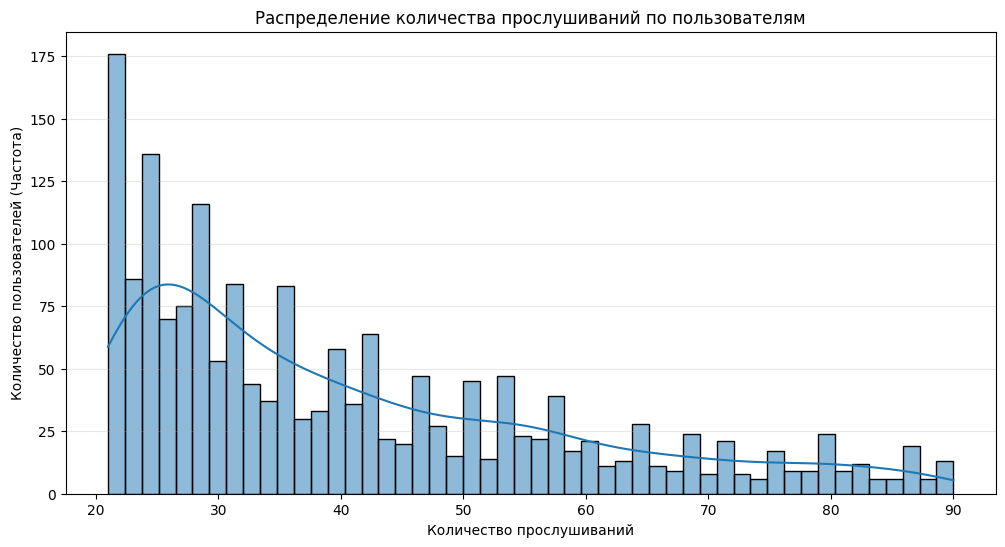

In [16]:
plt.figure(figsize=(12, 6))

sns.histplot(df_train_active['uid'].value_counts(), kde=True, bins=50)

plt.title('Распределение количества прослушиваний по пользователям')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (Частота)')
plt.grid(axis='y', alpha=0.3)
plt.show()

Стало получше. Мы убрали неактивных пользователей, убрали супер активных.

Может показаться странным, что за год люди слушали так мало треков, но эта статистика берется по данным с  explicit фидбеком, которого всегда меньше

In [17]:
df_train_active

,uid,timestamp,item_id,event_type
0,627100,19571995,453808,dislike
1,349300,19572125,1949803,like
2,349300,19572125,219150,like
3,559100,19572260,1044085,like
4,559100,19572260,2033546,like
...,...,...,...,...
73616,488000,25878780,6317616,like
73617,488000,25878780,5302349,like
73618,32500,25878800,3135264,like
73619,32500,25878800,5016149,like


In [18]:
df_train_active.uid.nunique(), df_train_active.item_id.nunique()

(1809, 35620)

Сейчас у нас есть следующие формы взаимодействия:
* Лайк
* Дизлайк
* Прослушивание

Из них нужно сформировать разные матрицы взаимодействий: бинарные, знаковые, взвешанные

Пока что мы делали препроцессинг для лайков и дизлайков, поэтому попробуем поработать только с этими видами фидбека 

In [19]:
counts = df_train_active.groupby(['uid', 'item_id'])['item_id'].transform('size')

duplicates_full = df_train_active[counts > 1].sort_values(by=['uid', 'item_id'])

duplicates_full.uid.nunique()

928

In [20]:
df_train_active.event_type.value_counts()

event_type
like       67654
dislike     5967
Name: count, dtype: int64

Тут видна такая ситуация: у нас 1809 пользователей, из которых тольо 928 совершали несколько действий (лайк и дизлайк), при этом большинство ставит лайки трекам. Думаю я сделаю такие взаимодействия: 
* значения -1 для дизлайков и 1 для лайков
* значения 0.1 для дизлайков и 1 для лайков. 

Для iALS буду использовать только 2-ой вариант, а для EASE, KNN попробую оба

In [21]:
train_df_sorted = train_df.sort_values(by=['uid', 'item_id', 'timestamp'])

final_states = train_df_sorted.drop_duplicates(subset=['uid', 'item_id'], keep='last').copy()

weight_mapping_sign = {
    'like': 1,
    'dislike': -1,
}

weight_mapping_weighted = {
    'like': 1,
    'dislike': 0.1,
}

final_states['interaction_sign'] = final_states['event_type'].map(weight_mapping_sign)
final_states['interaction_weighted'] = final_states['event_type'].map(weight_mapping_weighted)


user_item_sign = final_states[['uid', 'item_id', 'interaction_sign']].reset_index(drop=True)
user_item_weighted = final_states[['uid', 'item_id', 'interaction_weighted']].reset_index(drop=True)

In [22]:
train_users_sign = set(user_item_sign['uid'])
train_items_sign = set(user_item_sign['item_id'])

test_clean = test_df[
    test_df['uid'].isin(train_users_sign) &
    test_df['item_id'].isin(train_items_sign)
]

In [23]:
item2id = {k: v for v, k in enumerate(user_item_sign['item_id'].unique())}
user2id = {k: v for v, k in enumerate(user_item_sign['uid'].unique())}

id2item = {v: k for k, v in item2id.items()}
id2user = {v: k for k, v in user2id.items()}

In [24]:
user_item_sign['uidx'] = user_item_sign['uid'].map(user2id)
user_item_sign['item_idx'] = user_item_sign['item_id'].map(item2id)

user_item_weighted['uidx'] = user_item_weighted['uid'].map(user2id)
user_item_weighted['item_idx'] = user_item_weighted['item_id'].map(item2id)

In [25]:
user_item_sign

,uid,item_id,interaction_sign,uidx,item_idx
0,100,2263048,1,0,0
1,100,3526521,1,0,1
2,100,4927727,-1,0,2
3,100,5590855,1,0,3
4,300,1126058,1,1,4
...,...,...,...,...,...
177400,999900,1369814,1,7147,73211
177401,999900,1524105,1,7147,4486
177402,999900,2185191,1,7147,83
177403,999900,2467371,1,7147,25210


In [26]:
user_item_weighted

,uid,item_id,interaction_weighted,uidx,item_idx
0,100,2263048,1.0,0,0
1,100,3526521,1.0,0,1
2,100,4927727,0.1,0,2
3,100,5590855,1.0,0,3
4,300,1126058,1.0,1,4
...,...,...,...,...,...
177400,999900,1369814,1.0,7147,73211
177401,999900,1524105,1.0,7147,4486
177402,999900,2185191,1.0,7147,83
177403,999900,2467371,1.0,7147,25210


In [27]:
from scipy.sparse import csr_matrix

user_item_sign_sparse = csr_matrix(
    (
        user_item_sign['interaction_sign'],
        (user_item_sign['uidx'], user_item_sign['item_idx'])
    ),
    shape=(len(user2id), len(item2id))
)

user_item_weighted_sparse = csr_matrix(
    (
        user_item_weighted['interaction_weighted'],
        (user_item_weighted['uidx'], user_item_weighted['item_idx'])
    ),
    shape=(len(user2id), len(item2id))
)

Metrics import 

In [28]:
from metrics import (
    recall_at_k,
    precision_at_k,
    ndcg_at_k,
    map_at_k,
    hit_rate_at_k,
)

Истинные взаимодействия, пока без разделения на лайки/дизлайки

In [29]:
test_true = test_clean.groupby('uid')['item_id'].apply(set).to_dict()

UserKNN

In [30]:
from models import UserKNN

In [31]:
userknn_sign = UserKNN()
userknn_sign.fit(user_item_sign_sparse)

In [32]:
userknn_weighted = UserKNN()
userknn_weighted.fit(user_item_weighted_sparse)

In [33]:
recall_userknn_sign = recall_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_sign.predict
)
precision_userknn_sign = precision_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_sign.predict
)
ndcg_userknn_sign = ndcg_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_sign.predict
)
map_userknn_sign = map_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_sign.predict
)
hit_rate_userknn_sign = hit_rate_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_sign.predict
)

print('UserKNN sign NDCG@10:', ndcg_userknn_sign)
print('UserKNN sign Recall@10:', recall_userknn_sign)
print('UserKNN sign Precision@10:', precision_userknn_sign)
print('UserKNN sign MAP@10:', map_userknn_sign)
print('UserKNN sign HitRate@10:', hit_rate_userknn_sign)


UserKNN sign NDCG@10: 0.018443302814498373
UserKNN sign Recall@10: 0.022605363984674328
UserKNN sign Precision@10: 0.005656759348034516
UserKNN sign MAP@10: 0.012550069244700117
UserKNN sign HitRate@10: 0.05081495685522531


In [34]:
recall_userknn_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)
precision_userknn_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)
ndcg_userknn_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)
map_userknn_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)
hit_rate_userknn_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)

print('UserKNN weighted NDCG@10:', ndcg_userknn_weighted)
print('UserKNN weighted Recall@10:', recall_userknn_weighted)
print('UserKNN weighted Precision@10:', precision_userknn_weighted)
print('UserKNN weighted MAP@10:', map_userknn_weighted)
print('UserKNN weighted HitRate@10:', hit_rate_userknn_weighted)


UserKNN weighted NDCG@10: 0.01726529500171954
UserKNN weighted Recall@10: 0.022222222222222223
UserKNN weighted Precision@10: 0.005560882070949185
UserKNN weighted MAP@10: 0.011629232043302032
UserKNN weighted HitRate@10: 0.04985618408437201


ItemKNN

In [35]:
from models import ItemKNN

In [36]:
itemknn_sign = ItemKNN()
itemknn_sign.fit(user_item_sign_sparse)

In [37]:
itemknn_weighted = ItemKNN()
itemknn_weighted.fit(user_item_weighted_sparse)

In [38]:
recall_itemknn_sign = recall_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_sign.predict
)
precision_itemknn_sign = precision_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_sign.predict
)
ndcg_itemknn_sign = ndcg_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_sign.predict
)
map_itemknn_sign = map_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_sign.predict
)
hit_rate_itemknn_sign = hit_rate_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_sign.predict
)

print('ItemKNN sign NDCG@10:', ndcg_itemknn_sign)
print('ItemKNN sign Recall@10:', recall_itemknn_sign)
print('ItemKNN sign Precision@10:', precision_itemknn_sign)
print('ItemKNN sign MAP@10:', map_itemknn_sign)
print('ItemKNN sign HitRate@10:', hit_rate_itemknn_sign)


ItemKNN sign NDCG@10: 0.0029511193274001975
ItemKNN sign Recall@10: 0.0026819923371647508
ItemKNN sign Precision@10: 0.0006711409395973154
ItemKNN sign MAP@10: 0.002433951209118994
ItemKNN sign HitRate@10: 0.006711409395973154


In [39]:
recall_itemknn_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
precision_itemknn_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
ndcg_itemknn_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
map_itemknn_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
hit_rate_itemknn_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)

print('ItemKNN weighted NDCG@10:', ndcg_itemknn_weighted)
print('ItemKNN weighted Recall@10:', recall_itemknn_weighted)
print('ItemKNN weighted Precision@10:', precision_itemknn_weighted)
print('ItemKNN weighted MAP@10:', map_itemknn_weighted)
print('ItemKNN weighted HitRate@10:', hit_rate_itemknn_weighted)


ItemKNN weighted NDCG@10: 0.0036263692661736248
ItemKNN weighted Recall@10: 0.0030651340996168583
ItemKNN weighted Precision@10: 0.0007670182166826462
ItemKNN weighted MAP@10: 0.00292349602033207
ItemKNN weighted HitRate@10: 0.007670182166826462


ELSA


In [40]:
from models import ELSA

In [41]:
elsa_sign = ELSA()
elsa_sign.fit(user_item_sign_sparse)


In [42]:
elsa_weighted = ELSA()
elsa_weighted.fit(user_item_weighted_sparse)


In [43]:
recall_elsa_sign = recall_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_sign.predict,
)
precision_elsa_sign = precision_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_sign.predict,
)
ndcg_elsa_sign = ndcg_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_sign.predict,
)
map_elsa_sign = map_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_sign.predict,
)
hit_rate_elsa_sign = hit_rate_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_sign.predict,
)

print('ELSA sign NDCG@10:', ndcg_elsa_sign)
print('ELSA sign Recall@10:', recall_elsa_sign)
print('ELSA sign Precision@10:', precision_elsa_sign)
print('ELSA sign MAP@10:', map_elsa_sign)
print('ELSA sign HitRate@10:', hit_rate_elsa_sign)


ELSA sign NDCG@10: 0.01863238787045758
ELSA sign Recall@10: 0.022222222222222223
ELSA sign Precision@10: 0.005560882070949185
ELSA sign MAP@10: 0.012591045366692538
ELSA sign HitRate@10: 0.05081495685522531


In [44]:
recall_elsa_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)
precision_elsa_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)
ndcg_elsa_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)
map_elsa_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)
hit_rate_elsa_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)

print('ELSA weighted NDCG@10:', ndcg_elsa_weighted)
print('ELSA weighted Recall@10:', recall_elsa_weighted)
print('ELSA weighted Precision@10:', precision_elsa_weighted)
print('ELSA weighted MAP@10:', map_elsa_weighted)
print('ELSA weighted HitRate@10:', hit_rate_elsa_weighted)


ELSA weighted NDCG@10: 0.01811666253678027
ELSA weighted Recall@10: 0.021839080459770115
ELSA weighted Precision@10: 0.005465004793863854
ELSA weighted MAP@10: 0.012373266980170142
ELSA weighted HitRate@10: 0.04793863854266539


iALS


In [45]:
from models import iALS

In [46]:
ials_sign = iALS()
ials_sign.fit(user_item_sign_sparse)

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/checkpoint-5-bogdan-egor/bogdan/venv/lib/python3.13/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 25/25 [00:04<00:00,  5.88it/s]


In [47]:
ials_weighted = iALS()
ials_weighted.fit(user_item_weighted_sparse)

100%|██████████| 25/25 [00:04<00:00,  5.41it/s]


In [48]:
recall_ials_sign = recall_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=ials_sign.predict,
)
precision_ials_sign = precision_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=ials_sign.predict,
)
ndcg_ials_sign = ndcg_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=ials_sign.predict,
)
map_ials_sign = map_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=ials_sign.predict,
)
hit_rate_ials_sign = hit_rate_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=ials_sign.predict,
)

print('iALS sign NDCG@10:', ndcg_ials_sign)
print('iALS sign Recall@10:', recall_ials_sign)
print('iALS sign Precision@10:', precision_ials_sign)
print('iALS sign MAP@10:', map_ials_sign)
print('iALS sign HitRate@10:', hit_rate_ials_sign)


iALS sign NDCG@10: 0.016155826557738975
iALS sign Recall@10: 0.022605363984674328
iALS sign Precision@10: 0.005656759348034516
iALS sign MAP@10: 0.009623542183465481
iALS sign HitRate@10: 0.052732502396931925


In [49]:
recall_ials_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)
precision_ials_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)
ndcg_ials_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)
map_ials_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)
hit_rate_ials_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)

print('iALS weighted NDCG@10:', ndcg_ials_weighted)
print('iALS weighted Recall@10:', recall_ials_weighted)
print('iALS weighted Precision@10:', precision_ials_weighted)
print('iALS weighted MAP@10:', map_ials_weighted)
print('iALS weighted HitRate@10:', hit_rate_ials_weighted)


iALS weighted NDCG@10: 0.01680118129913165
iALS weighted Recall@10: 0.02413793103448276
iALS weighted Precision@10: 0.006040268456375839
iALS weighted MAP@10: 0.00956778498125574
iALS weighted HitRate@10: 0.05656759348034516


TopPopular, TopPersonal, TopPersonal+TopPopular

In [50]:
from models import TopPopular, TopPersonal, TopPersonalTopPopular

top_popular_sign = TopPopular()
top_popular_sign.fit(user_item_sign_sparse)

top_popular_weighted = TopPopular()
top_popular_weighted.fit(user_item_weighted_sparse)

top_personal_sign = TopPersonal()
top_personal_sign.fit(user_item_sign_sparse)

top_personal_weighted = TopPersonal()
top_personal_weighted.fit(user_item_weighted_sparse)

hybrid_sign = TopPersonalTopPopular()
hybrid_sign.fit(user_item_sign_sparse)

hybrid_weighted = TopPersonalTopPopular()
hybrid_weighted.fit(user_item_weighted_sparse)


In [51]:
def print_metrics_all(label, model, R, k=10):
    fn = model.predict
    print(f"=== {label} ===")
    print(f"Recall@{k}:", recall_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"Precision@{k}:", precision_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"NDCG@{k}:", ndcg_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"MAP@{k}:", map_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"HitRate@{k}:", hit_rate_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print()


for name, m, R in [
    ("TopPopular sign", top_popular_sign, user_item_sign_sparse),
    ("TopPopular weighted", top_popular_weighted, user_item_weighted_sparse),
    ("TopPersonal sign", top_personal_sign, user_item_sign_sparse),
    ("TopPersonal weighted", top_personal_weighted, user_item_weighted_sparse),
    ("TopPersonal+TopPopular sign", hybrid_sign, user_item_sign_sparse),
    ("TopPersonal+TopPopular weighted", hybrid_weighted, user_item_weighted_sparse),
]:
    print_metrics_all(name, m, R)


=== TopPopular sign ===
Recall@10: 0.011494252873563218
Precision@10: 0.0028763183125599234
NDCG@10: 0.00662573987045693
MAP@10: 0.003507916216449294
HitRate@10: 0.02588686481303931

=== TopPopular weighted ===
Recall@10: 0.011877394636015325
Precision@10: 0.002972195589645254
NDCG@10: 0.00627244140578749
MAP@10: 0.002999365045545934
HitRate@10: 0.024928092042186004

=== TopPersonal sign ===
Recall@10: 0.022605363984674328
Precision@10: 0.005656759348034516
NDCG@10: 0.018443302814498373
MAP@10: 0.012550069244700117
HitRate@10: 0.05081495685522531

=== TopPersonal weighted ===
Recall@10: 0.022222222222222223
Precision@10: 0.005560882070949185
NDCG@10: 0.01726529500171954
MAP@10: 0.011629232043302032
HitRate@10: 0.04985618408437201

=== TopPersonal+TopPopular sign ===
Recall@10: 0.01800766283524904
Precision@10: 0.004506232023010546
NDCG@10: 0.016973189799163187
MAP@10: 0.012031704180553653
HitRate@10: 0.04314477468839885

=== TopPersonal+TopPopular weighted ===
Recall@10: 0.017624521072